In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pickle
import shap
from shap.plots import waterfall
import lime

from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from utils.helpers import Helpers

In [2]:
helper = Helpers()
properties = helper.load_properties()

try:
    RANDOM_STATE = properties['models']['random_state']
except KeyError as ke:
    raise KeyError(f"Missing key in properties file: {str(ke)}") from ke

In [3]:
# Apply global settings
helper.set_global_settings()

In [4]:
target_variable = 'loan_status'
parent_data_dir = helper.root_dir / "datasets"

train_df = pd.read_csv(parent_data_dir / "sampled_train_data.csv")
test_df = pd.read_csv(parent_data_dir / "test_set.csv")

X_train = train_df.drop(columns=[target_variable])
y_train = train_df[target_variable]

X_test = test_df.drop(columns=[target_variable])
y_test = test_df[target_variable]

In [5]:
parent_model_dir = helper.root_dir / "models"

with open(parent_model_dir / "best_model.pkl", "rb") as f:
    model = pickle.load(f)

with open(parent_model_dir / "power_transformer.pkl", "rb") as f:
    transformer = pickle.load(f)

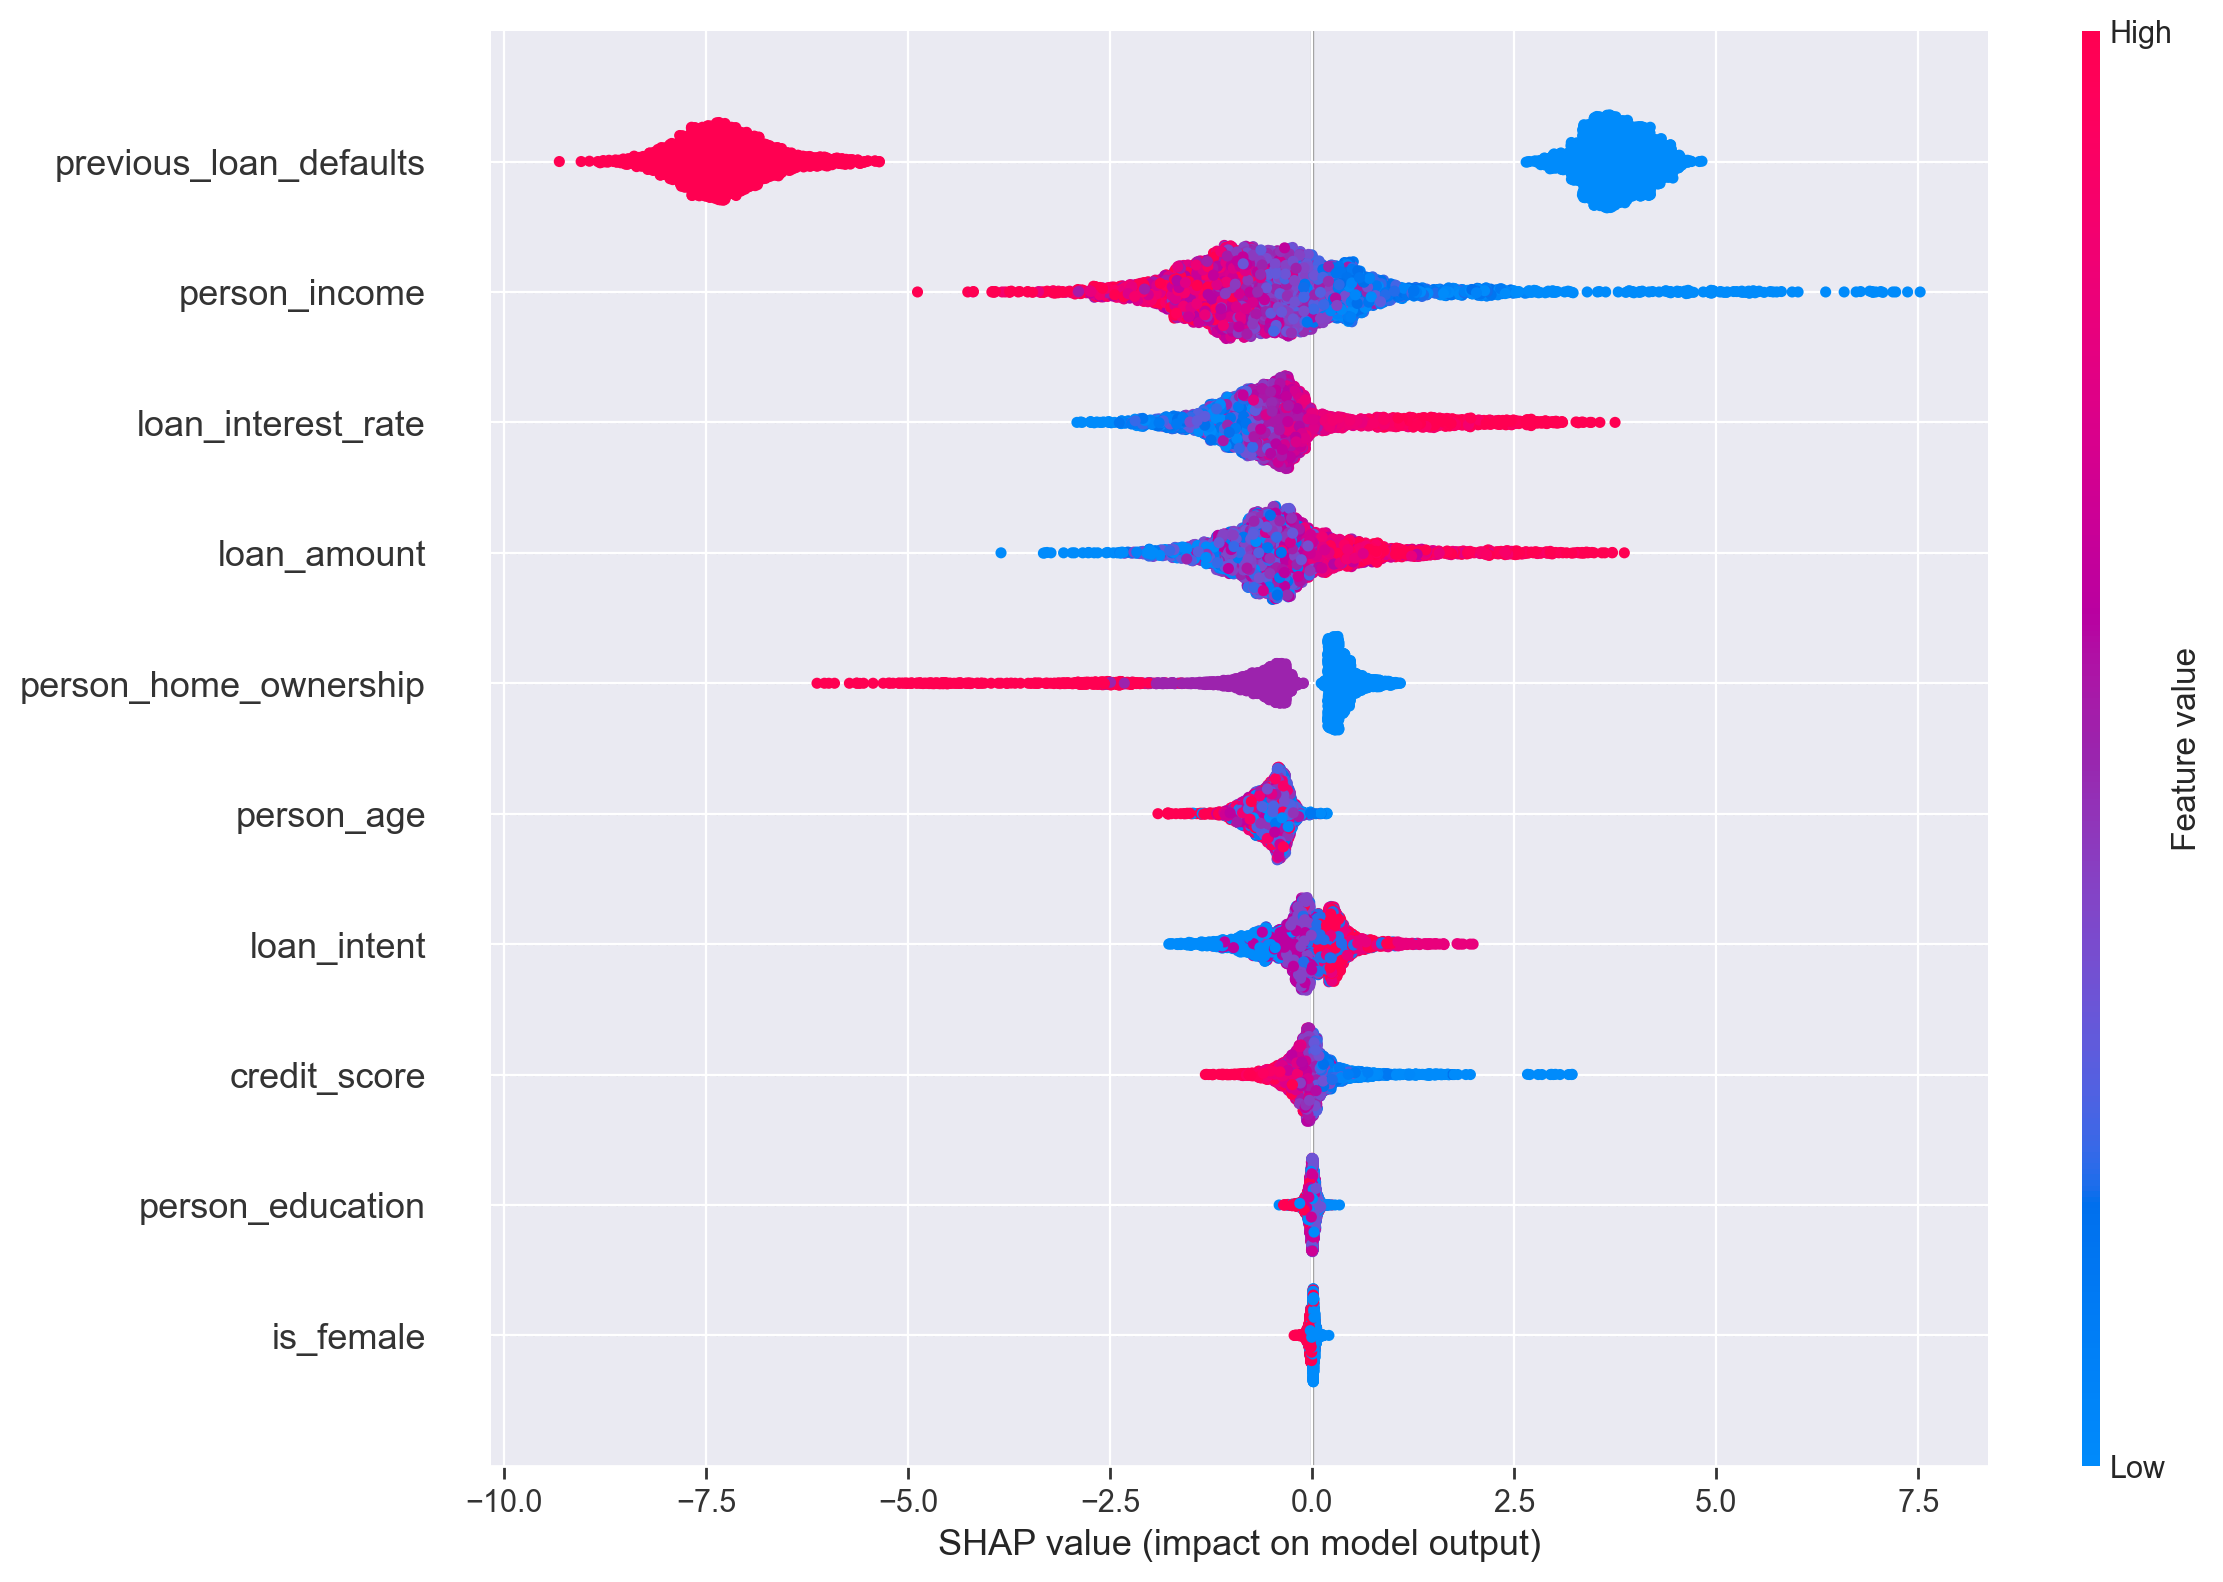

<Figure size 1280x960 with 0 Axes>

In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test, y_test)

shap.summary_plot(shap_values, X_test, plot_size=(12,8))
plt.tight_layout()

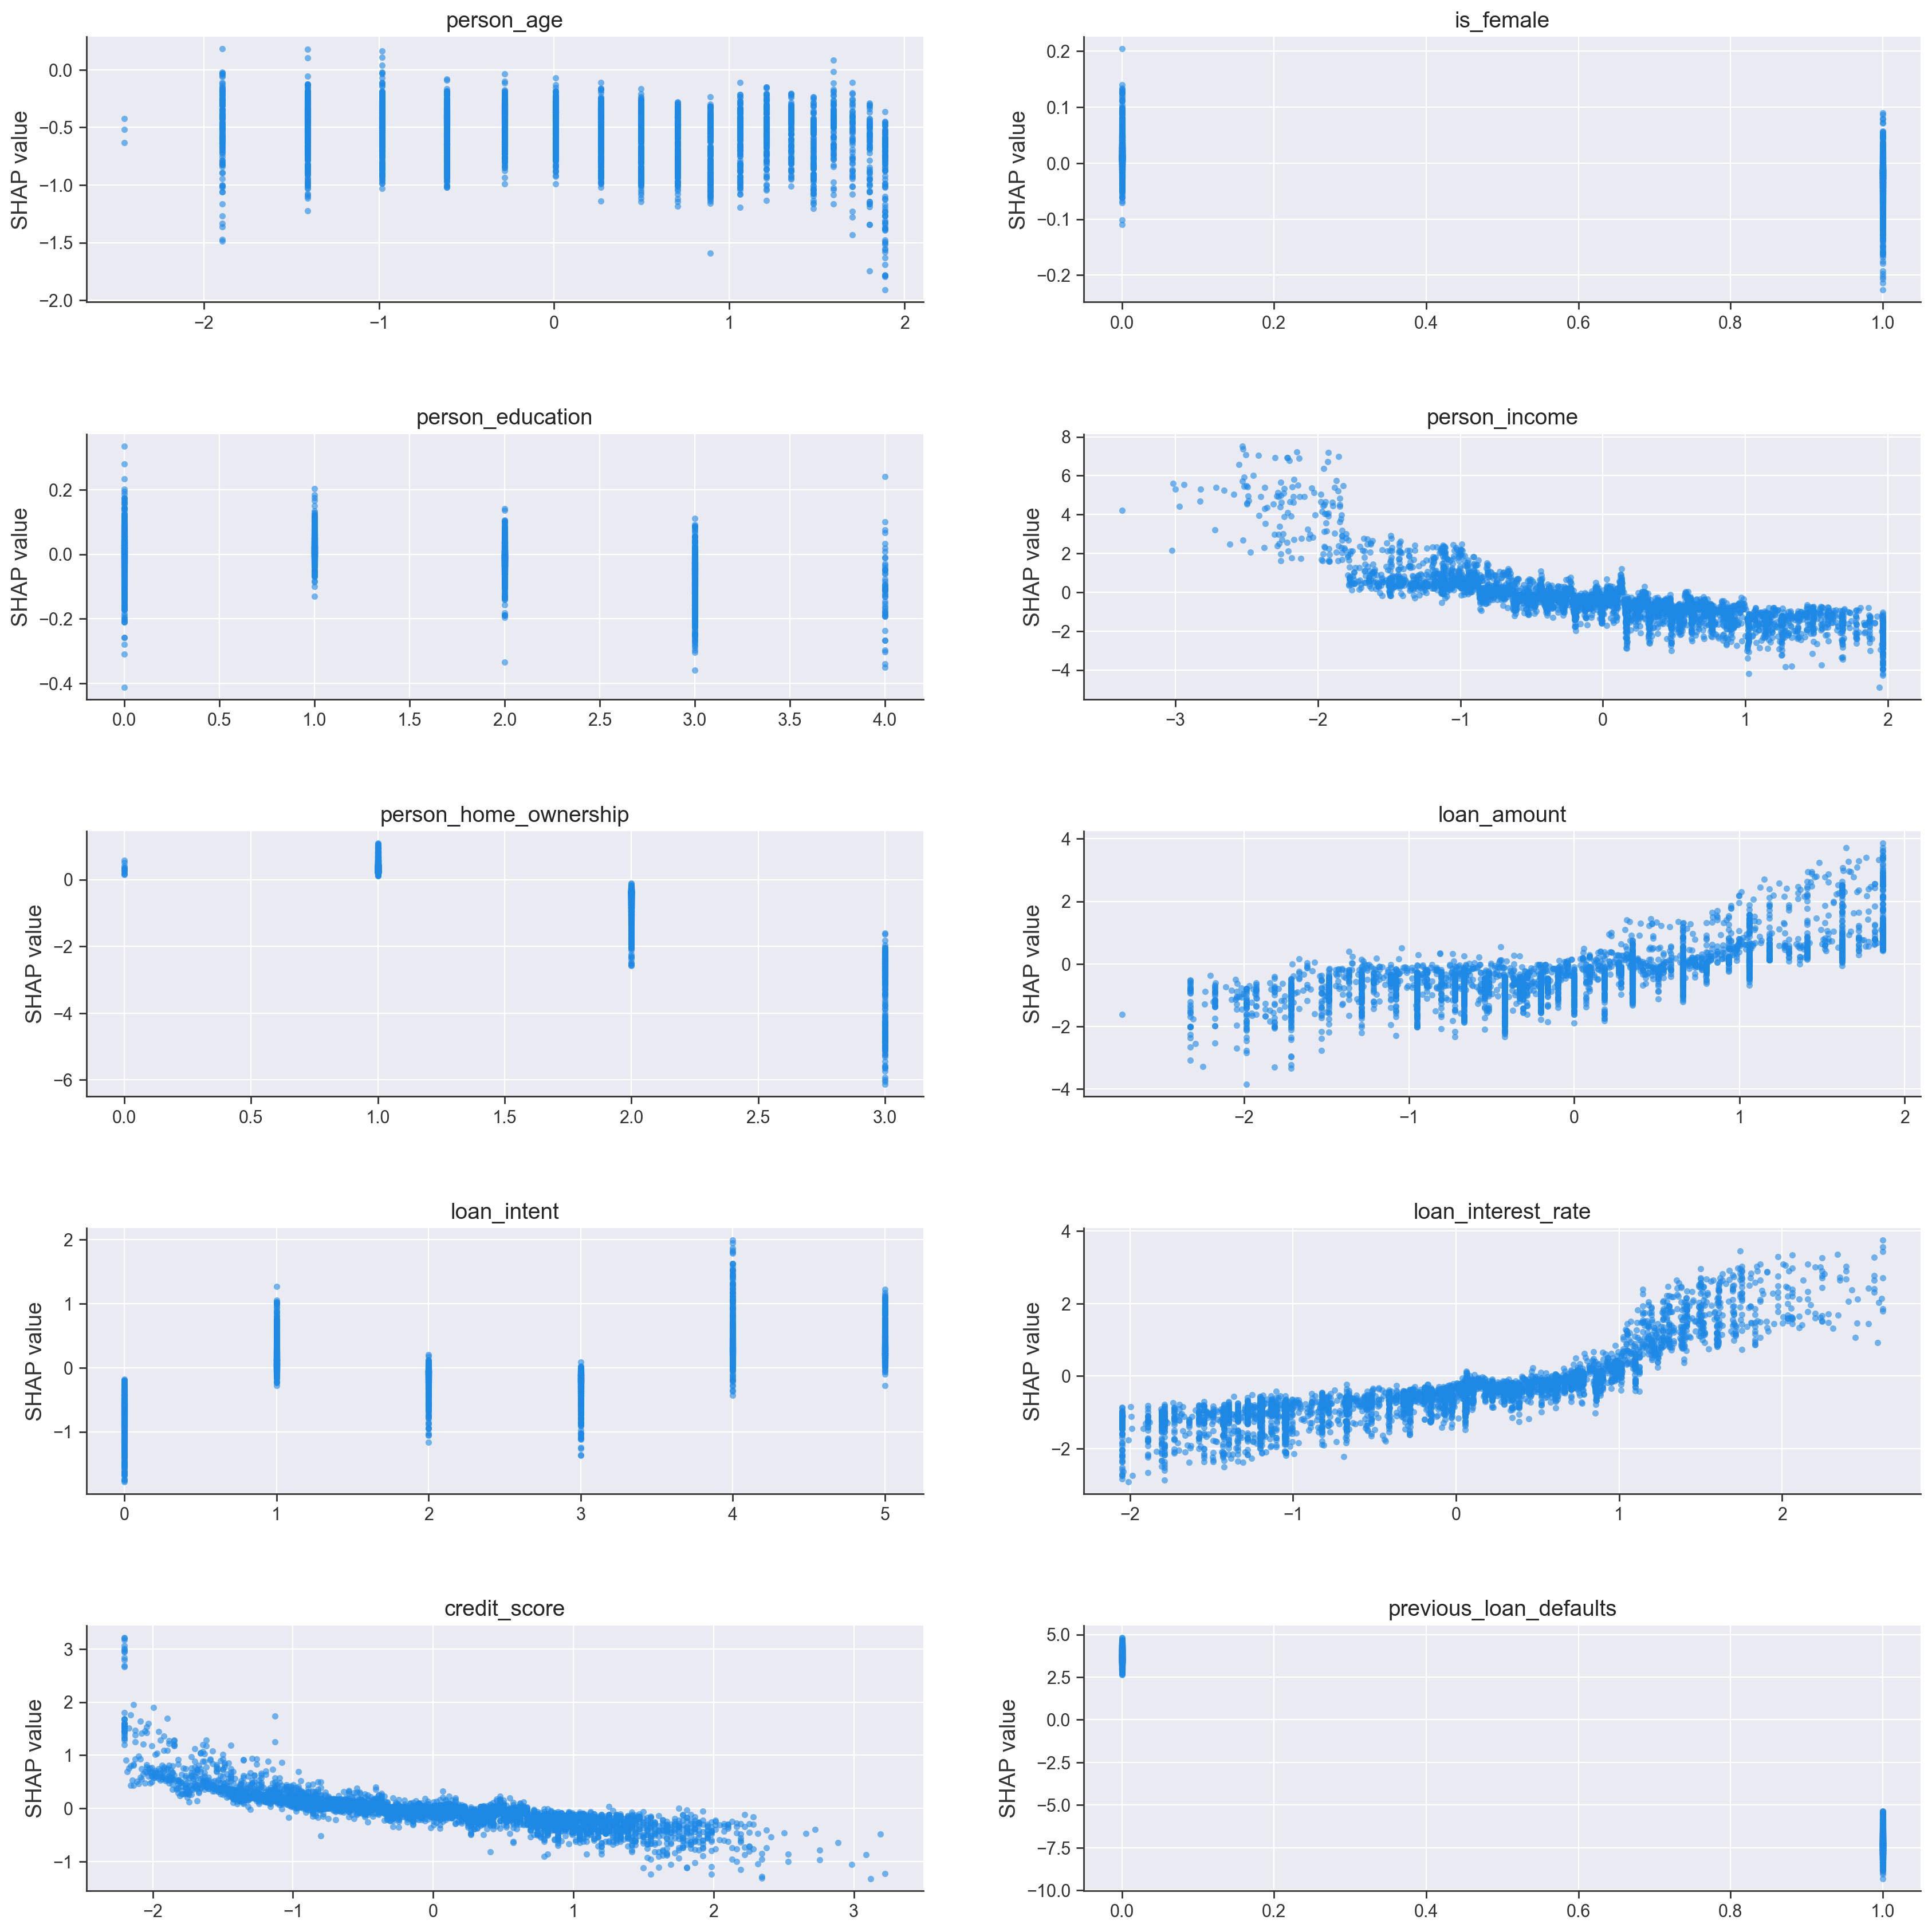

In [7]:
features = X_train.columns.to_list()

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(18,18))
axes = axes.flatten()

for ax, f in zip(axes, features):
    plt.sca(ax)
    shap.dependence_plot(
        f,
        shap_values,
        X_test,
        interaction_index=None,
        alpha=0.6,
        ax=ax,
        show=False
    )
    ax.set_title(f, fontsize=14)
    ax.set_ylabel("SHAP value", fontsize=14)
    ax.set_xlabel("")

plt.tight_layout(pad=5)
plt.show()

In [27]:
import numpy as np

shap_explanation_object = explainer(X_test)

# predicted probabilities for positive class
y_proba = model.predict_proba(X_test)[:, 1]

# most positive prediction
pos_idx = np.argmax(y_proba)

# most negative prediction
neg_idx = np.argmin(y_proba)

print("Positive index:", pos_idx, "prob:", y_proba[pos_idx])
print("Negative index:", neg_idx, "prob:", y_proba[neg_idx])

Positive index: 1951 prob: 0.9999609135519145
Negative index: 1557 prob: 1.851656090956203e-06


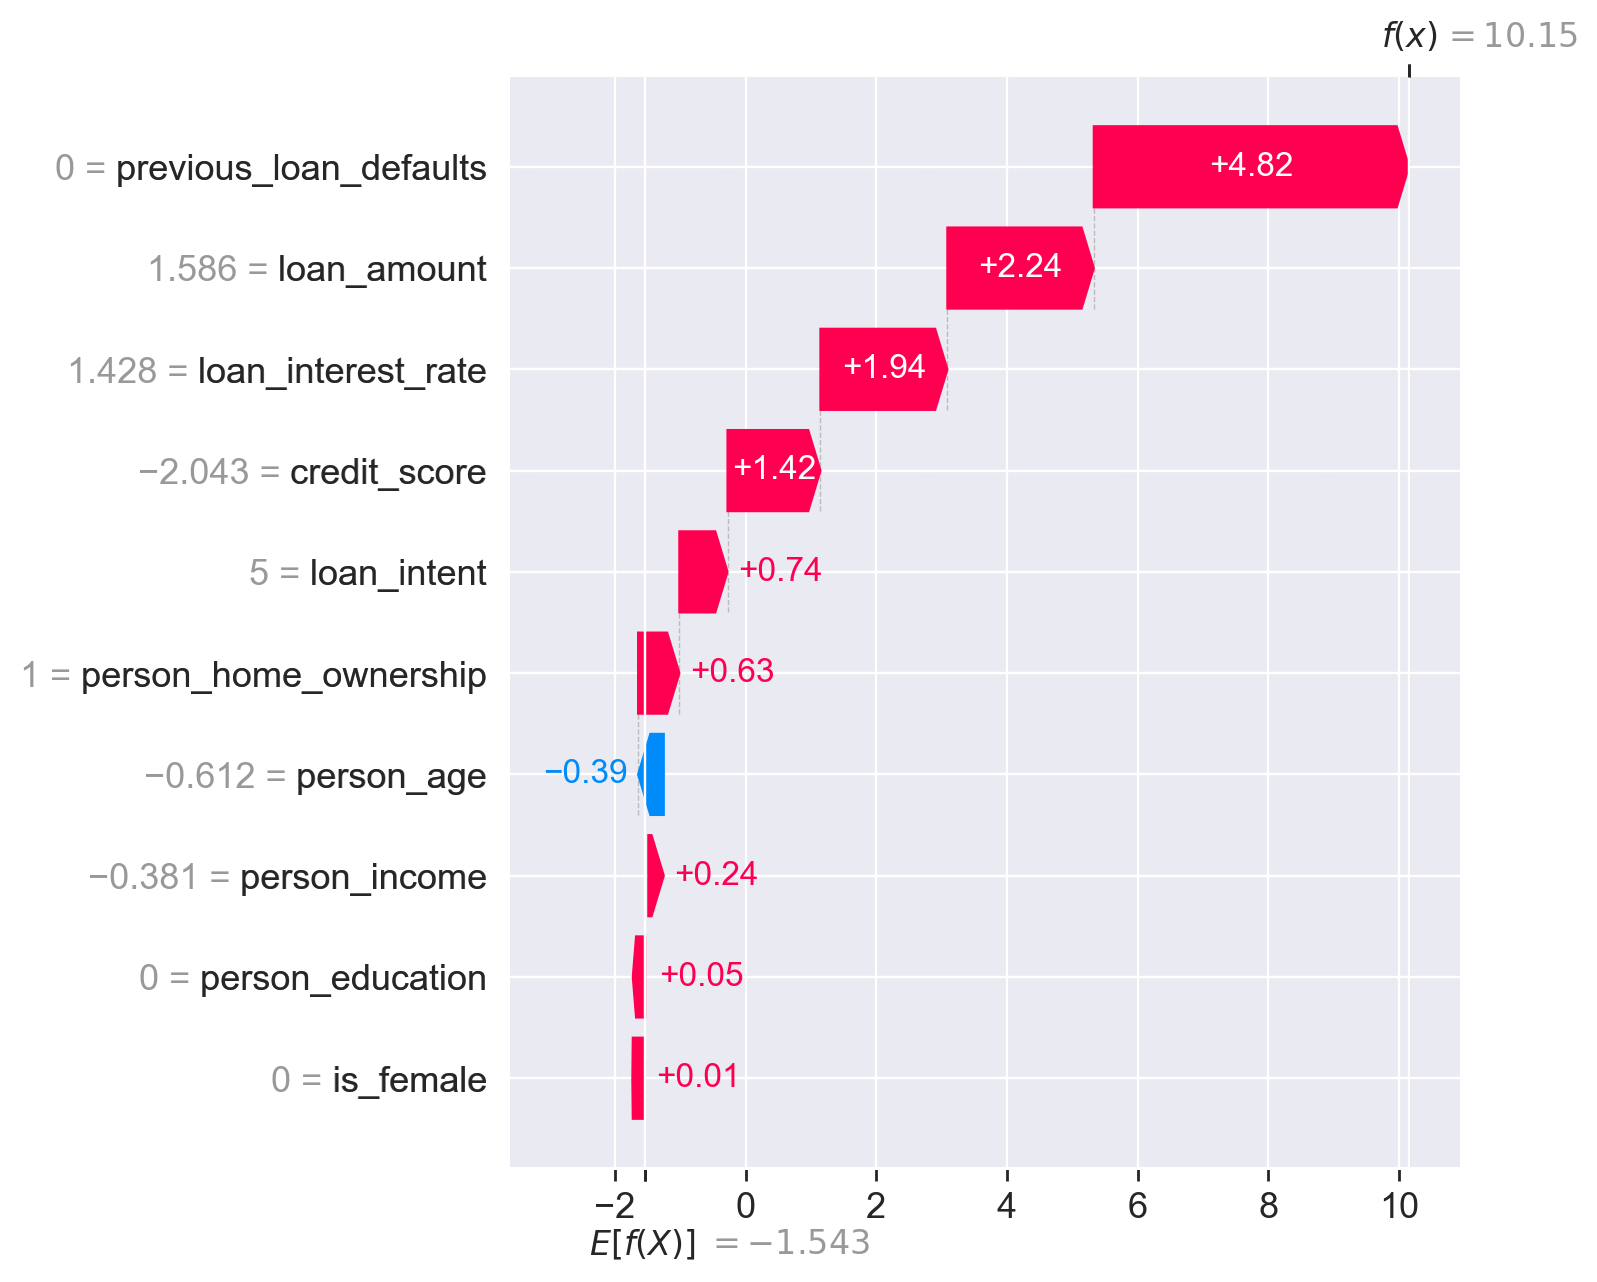

In [37]:
plt.figure(figsize=(20,12))
waterfall(shap_explanation_object[pos_idx], show=False)
plt.tight_layout()
plt.show()

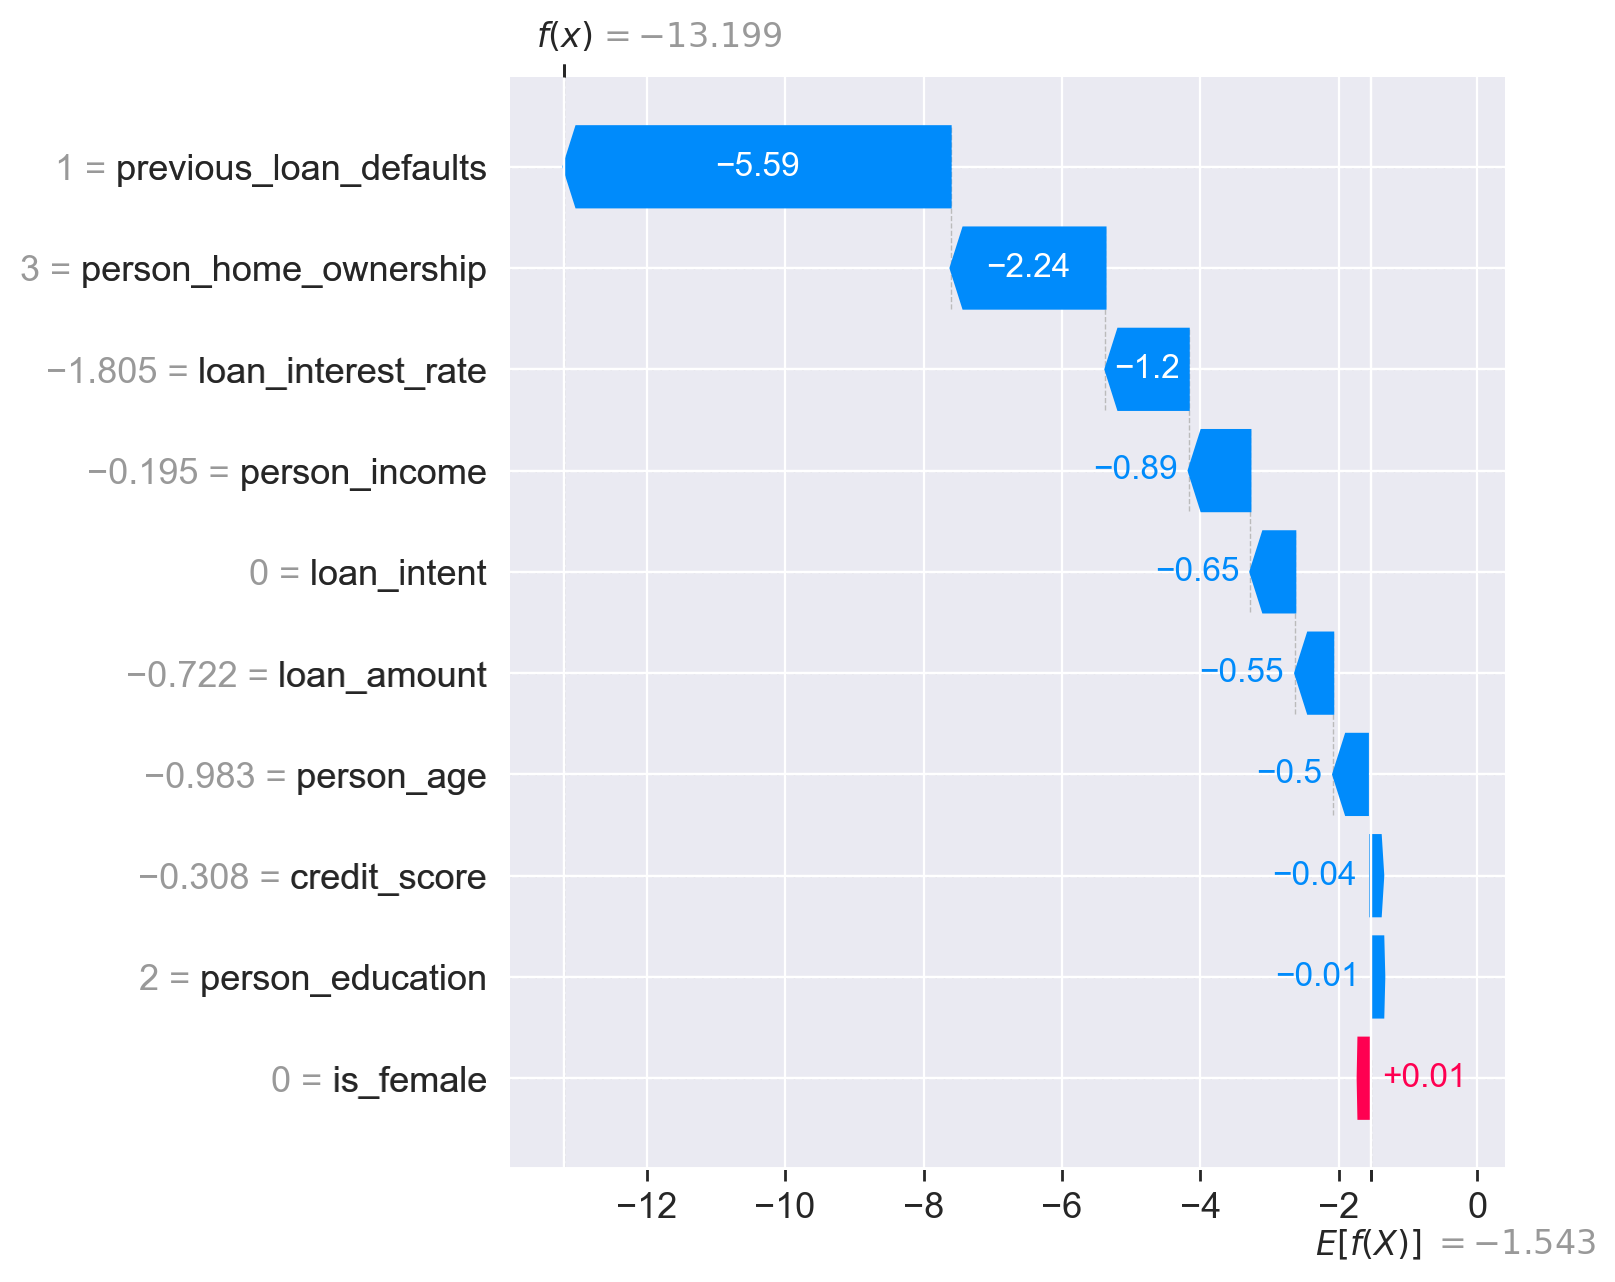

In [36]:
plt.figure(figsize=(10,6))
waterfall(shap_explanation_object[neg_idx], show=False)
plt.tight_layout()
plt.show()

In [38]:
shap_explanation_object[neg_idx]

.values =
array([-0.50073546,  0.01137236, -0.01485941, -0.89092713, -2.23687711,
       -0.54784124, -0.64808318, -1.20187875, -0.03672964, -5.58993694])

.base_values =
np.float64(-1.5429317734162296)

.data =
array([-0.98327118,  0.        ,  2.        , -0.19508742,  3.        ,
       -0.72223338,  0.        , -1.80538199, -0.30826914,  1.        ])

In [40]:
shap_values[0]

array([-4.07549482e-01,  1.04159120e-02,  4.54605742e-02, -2.24435652e-01,
       -3.16724103e-01, -2.90031510e-01, -3.70224418e-01, -3.02850406e-01,
        6.06194907e-03, -7.25961778e+00])